# Market Regime Detection using K-Means Clustering

## Objective

The objective of this notebook is to identify hidden market regimes within Bitcoin price behavior using unsupervised machine learning.

After transforming the original financial features through Principal Component Analysis (PCA), we apply K-Means clustering to group observations with similar characteristics.

These clusters may represent different market conditions such as:

- Bull Markets
- Bear Markets
- Sideways Markets
- Transitional Periods

Unlike supervised learning, no regime labels are provided to the model. Instead, the algorithm discovers patterns directly from the data.

The resulting clusters will serve as the foundation for the market regime detection system developed in this project.

Clustering is performed on the PCA-transformed dataset rather than the original engineered features.

The PCA components provide a compact representation of market behavior by combining information from returns, volatility, and momentum while reducing redundancy between variables.

Using the PCA feature space can improve cluster separation and facilitate the identification of meaningful market regimes.

-----

## Load PCA Dataset

In this section, we load the dataset generated during the PCA stage.

This dataset contains the principal components that will be used as inputs for the clustering algorithm.

The objective is to verify that the PCA transformation was successfully saved and can be loaded correctly for the market regime detection process.

In [1]:
# ==========================================
# Import Libraries and Load Configuration
# ==========================================
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import os 
import sys

# Absoulte Path To The Project Route
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [2]:
# ==========================================
# Load PCA Dataset
# ==========================================
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

pca_path =(
    f"{PROCESSED_DATA_PATH}/"
    f"{asset_name}_pca.csv"
)

feature_path = (
    f"{PROCESSED_DATA_PATH}/"
    f"{asset_name}_features.csv"
)


df = pd.read_csv(pca_path)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

------

## Dataset Verification

Before applying clustering algorithms, we verify the structure of the PCA-transformed dataset.

The dataset should contain the principal components generated during the dimensionality reduction stage and will serve as the feature space used to identify potential market regimes.

In [3]:
# ==========================================
# Verification
# ==========================================
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 3114 entries, 2018-01-31 to 2026-08-10
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     3114 non-null   float64
 1   PC2     3114 non-null   float64
 2   PC3     3114 non-null   float64
dtypes: float64(3)
memory usage: 97.3 KB


,PC1,PC2,PC3
count,3.114000e+03,3114.000000,3.114000e+03
mean,-4.563537e-18,0.000000,-4.563537e-18
std,1.128051e+00,1.001370,8.518937e-01
min,-1.060131e+01,-1.690164,-5.234789e+00
25%,-5.395822e-01,-0.682733,-4.640822e-01
50%,-3.354362e-02,-0.196430,-4.417993e-02
75%,5.446646e-01,0.470755,4.026048e-01
max,6.141801e+00,4.978805,5.853268e+00


### Interpretation

The PCA-transformed dataset contains 3,065 observations represented by three principal components (PC1, PC2, and PC3), providing a compact representation of market behavior suitable for clustering analysis.

No missing values were detected, and all principal components are stored as numerical variables, satisfying the requirements of the K-Means algorithm.

The principal components are centered around zero, which is expected after feature standardization and PCA transformation. Additionally, the decreasing standard deviations across components reflect the variance hierarchy identified during the PCA stage, where PC1 captures the largest proportion of information and PC3 captures the smallest.

Overall, the dataset appears clean, consistent, and ready for unsupervised learning. The principal component space will be used to identify potential market regimes through clustering techniques.

-----

## Clustering Workflow Overview

Clustering is an unsupervised learning technique used to identify groups of observations that exhibit similar characteristics.

In this project, clustering is applied to the PCA-transformed feature space to discover potential market regimes. Rather than using predefined labels, the algorithm will automatically group observations based on their similarity in terms of the principal components extracted during the dimensionality reduction stage.

The clustering workflow consists of the following steps:

1. Determine an appropriate number of clusters.
2. Train the clustering model.
3. Assign each observation to a cluster.
4. Visualize cluster separation in PCA space.
5. Interpret the resulting market regimes.

The ultimate objective is to identify recurring patterns of market behavior that may correspond to distinct financial conditions such as bullish, bearish, or high-volatility environments.

### Methods of clustering 
The Elbow Method and Silhouette Score provide complementary perspectives on clustering quality.

The Elbow Method evaluates cluster compactness by measuring the within-cluster sum of squares, while the Silhouette Score evaluates how well separated the clusters are from one another.

Using both metrics reduces the risk of selecting a cluster configuration that is either overly fragmented or insufficiently distinct, leading to a more robust identification of market regimes.

-----

## Cluster Selection Analysis

Before training the final clustering model, multiple values of K will be evaluated to determine an appropriate number of clusters.

The evaluation will be based on both the Elbow Method and the Silhouette Score. Together, these metrics provide complementary information regarding cluster compactness and cluster separation.

The objective is to identify candidate cluster configurations that can later be analyzed from a financial perspective.

In [4]:
# ==========================================
# Import Clustering Tools
# ==========================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
# ==========================================
# Store Evaluation Metrics
# ==========================================

inertia_scores = []
silhouette_scores = []
k_values = []

In [6]:
# ==========================================
# Evaluate Different Cluster Configurations
# ==========================================
for k in range(MIN_CLUSTERS, MAX_CLUSTERS + 1):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(df)

    inertia_scores.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(df, cluster_labels))

    k_values.append(k)

In [7]:
# ==========================================
# Evaluation Table
# ==========================================
evaluation_df = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

evaluation_df

,K,Inertia,Silhouette Score
0,2,7166.346109,0.302394
1,3,5581.139939,0.312794
2,4,4777.350940,0.322255
3,5,4299.967842,0.312167
4,6,3845.381963,0.251939
5,7,3551.271441,0.247670
6,8,3298.169042,0.229482
7,9,3059.505524,0.247507
8,10,2871.931853,0.233895


### Interpretation

The clustering evaluation was performed using both the Elbow Method (Inertia) and the Silhouette Score across cluster configurations ranging from K=2 to K=10.

As expected, inertia decreases monotonically as the number of clusters increases, indicating improved within-cluster compactness. However, inertia alone cannot determine the optimal number of clusters because additional clusters will almost always reduce the metric.

The Silhouette Score provides additional insight by evaluating the balance between cluster cohesion and separation. The highest score was obtained for K=4 (0.318), while K=3 and K=5 also produced competitive results.

These results suggest that the most promising cluster configurations lie between three and five clusters. Consequently, these candidate values will be further analyzed before selecting the final market regime structure.

-----

## Elbow Method Analysis

The Elbow Method is used to evaluate how cluster compactness changes as the number of clusters increases.

For each value of K, the within-cluster sum of squares (Inertia) is calculated. Lower inertia values indicate that observations are closer to their assigned centroids.

The objective is to identify a point where adding additional clusters provides diminishing improvements. This point, commonly referred to as the "elbow", represents a potential candidate for the optimal number of clusters.

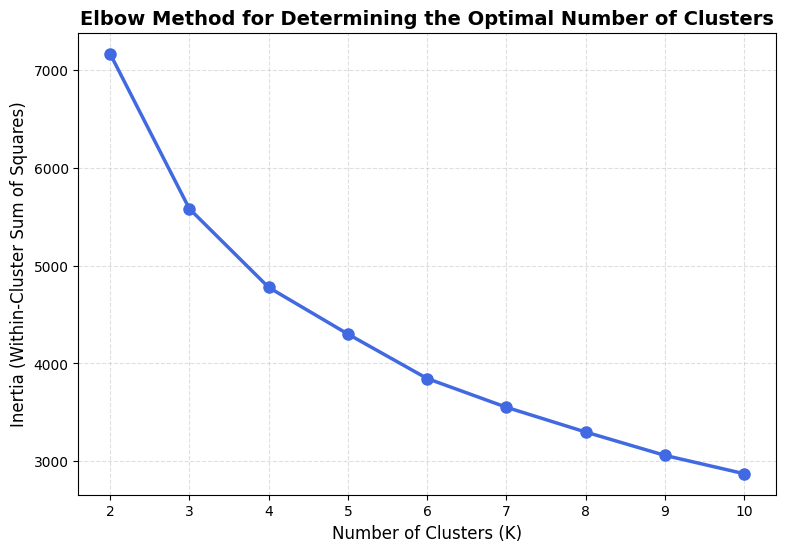

In [8]:
# ==========================================
# Elbow Method
# ==========================================

# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)


### Initial Observation
Looking at the metric evaluation table, we observe a steady drop in **Inertia** as the number of clusters ($K$) increases from 2 to 10. 
* A massive drop occurs moving from $K=2$ ($7057.93$) to $K=3$ ($5260.62$), and then to $K=4$ ($4709.18$).
* After $K=4$, the margin of decrease begins to shrink significantly (e.g., changing by only ~200-300 points per step).

This suggests an optimal structural change ("elbow") likely exists around **$K=3$ or $K=4$**. To confirm the exact location of this inflection point, we generate a visual Elbow plot below.

#### Chart With The Interpretation

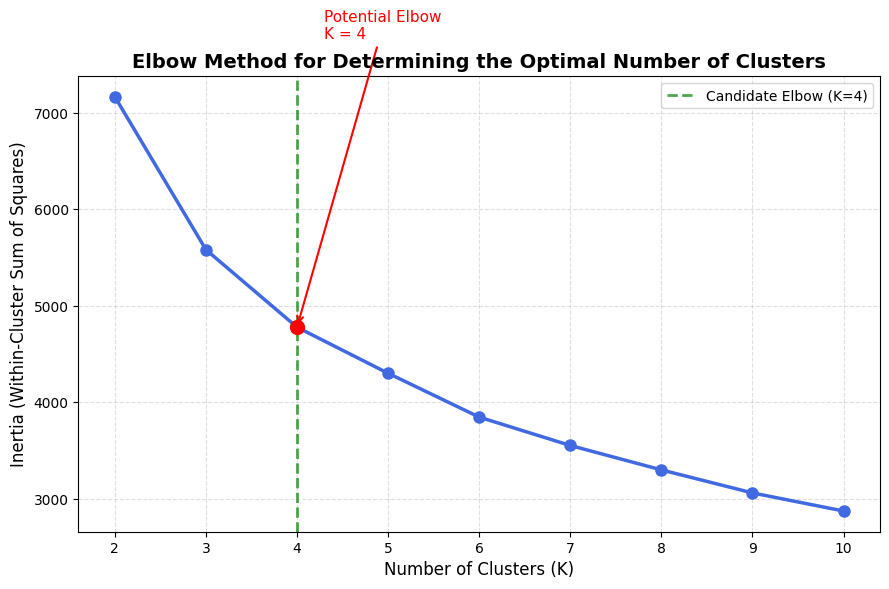

In [9]:
# ==========================================
# Candidate Elbow Method
# ==========================================

# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

# Highlight the candidate elbow
candidate_k = 4 
plt.axvline(
    x = candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Candidate Elbow (K=4)"
)

plt.scatter(
    candidate_k,
    inertia_scores[candidate_k - MIN_CLUSTERS],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    "Potential Elbow\nK = 4",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0] + 600),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    fontsize=11,
    color="red"
)

plt.legend()

plt.tight_layout()
plt.show()

### Final Interpretation: Elbow Analysis
The visual plot confirms that the steepest rate of descent occurs between $K=2$ and $K=4$. Beyond $K=4$, the curve visibly flattens into a linear trajectory with diminishing returns. 

While $K=3$ presents a minor inflection point, $K=4$ provides the cleanest "elbow" where the trade-off between cluster tightness (low inertia) and model complexity is minimized. This suggests that increasing K beyond approximately 4 provides progressively smaller improvements in within-cluster compactness. Therefore, K=4 is considered a reasonable candidate for further evaluation.

------

## Silhouette Score Analysis

The Silhouette Score is used to evaluate the quality of cluster separation and cohesion across different values of K.

For each observation, the silhouette coefficient measures how similar it is to its own cluster compared to the next closest cluster. The average score across the entire dataset ranges from -1 to +1, where higher values indicate that data points are well-matched to their own regime and distinctly separated from neighboring regimes.

The objective is to identify a peak in the score curve. Unlike inertia, which always decreases as K increases, the Silhouette Score helps us prevent over-clustering by highlighting the configuration where the market regimes remain structurally distinct and do not blend into each other.

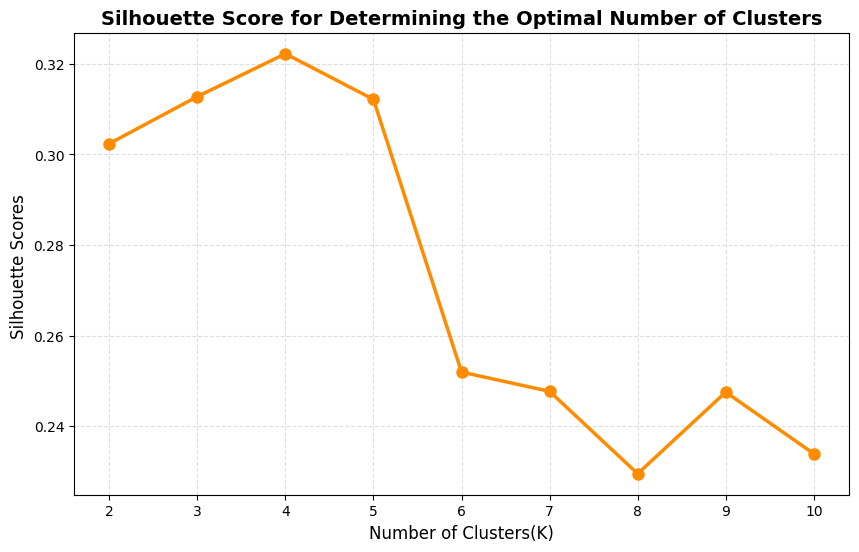

In [10]:
# ==========================================
# Silhouette Scores
# ==========================================

# Plot the Silhouette Scores
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker = 'o',
    markersize = 8,
    linewidth = 2.5,
    color = 'darkorange'
)

plt.xlabel("Number of Clusters(K)", fontsize=12)
plt.ylabel("Silhouette Scores ", fontsize=12)
plt.title("Silhouette Score for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

### Initial Observation
The Silhouette Score evaluates cluster separation and cohesion. Looking at our tabular data:
* $K=2$ starts at $0.298$, showing moderate structural separation.
* The score increases as we add clusters, pointing to better-defined groupings.
* It reaches its global maximum exactly at **$K=4$ with a score of $0.318$**.

Any further increase in clusters ($K \ge 5$) causes the score to deteriorate rapidly, indicating that the algorithm is forcing arbitrary splits on well-defined groups. We will plot this curve next to identify the peak explicitly.

#### Chart With The Interpretation

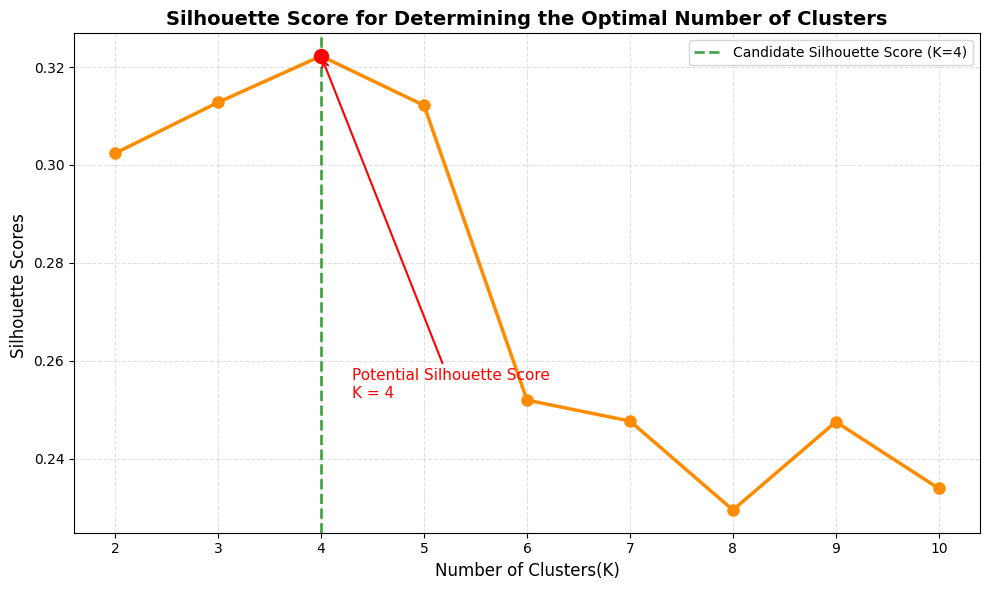

In [11]:
# ==========================================
# Candidate Silhouette Scores
# ==========================================

# Plot the Silhouette Scores
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker = 'o',
    markersize = 8,
    linewidth = 2.5,
    color = 'darkorange'
)

plt.xlabel("Number of Clusters(K)", fontsize=12)
plt.ylabel("Silhouette Scores ", fontsize=12)
plt.title("Silhouette Score for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

# Highlight the candidate silhouette score  
candidate_k = 4
plt.axvline(
    x = candidate_k,
    color = "green",
    linestyle = "--",
    linewidth=2,
    alpha=0.7,
    label = "Candidate Silhouette Score (K=4)"
)

plt.scatter(
    candidate_k, 
    silhouette_scores[candidate_k - MIN_CLUSTERS],
    color = "red",
    s = 100,
    zorder = 5
)

plt.annotate(
    "Potential Silhouette Score\nK = 4",
    xy=(candidate_k, silhouette_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, silhouette_scores[0] - 0.05),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    fontsize=11,
    color="red"
)

plt.legend()

plt.tight_layout()
plt.show()

### Final Interpretation: Silhouette Analysis

The Silhouette Score reaches its highest value at **K=4**, with a score of approximately **0.318**. This indicates that K=4 provides the best balance between cluster cohesion and separation among the configurations evaluated.

However, the absolute silhouette value indicates that the separation between clusters is moderate rather than highly distinct. Therefore, the result should be interpreted as evidence that K=4 is the strongest configuration among those tested, rather than as proof of perfectly separated market regimes.

The decline in the score for K=5 and higher suggests that increasing the number of clusters does not improve the overall separation of the observations.

----

## Combined Metric Analysis

The Elbow Method and the Silhouette Score evaluate different aspects of clustering quality.

Rather than relying on a single metric, both results are analyzed together to identify the most promising cluster configurations before selecting the final K-Means model.

To make a robust final decision on the optimal number of market regimes, we evaluate the Elbow Method and the Silhouette Score simultaneously.

Relying on a single metric can lead to suboptimal choices—Inertia alone may favor an excessively high number of clusters, while the Silhouette Score might favor an oversimplified structure. By overlaying both metrics, we look for a point of convergence: a value of K that sits at a clear "elbow" of diminishing returns for internal tightness, while simultaneously capturing a local or global peak in cluster separation.

This dual-perspective approach ensures our final market states are both mathematically optimized and practically viable for asset allocation.

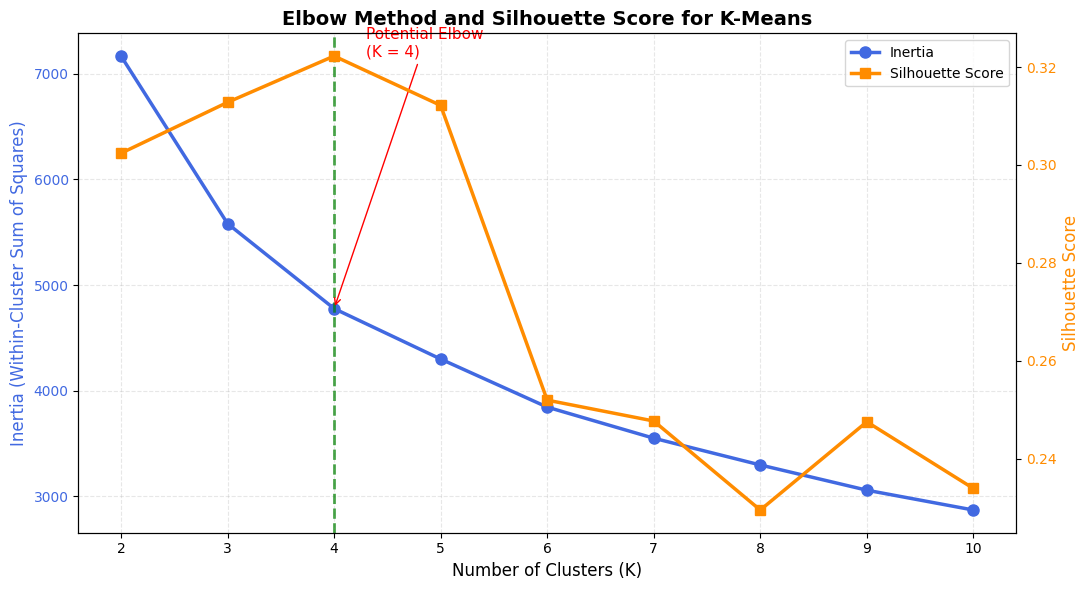

In [12]:
# ==========================================
# Plot Both Methods
# ==========================================

# Plot Elbow Method and Silhouette Score

fig, ax1 = plt.subplots(figsize=(11, 6))

# -------------------------
# Elbow Method (Inertia)
# -------------------------
ax1.plot(
    k_values,
    inertia_scores,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="royalblue",
    label="Inertia"
)

ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)",
               fontsize=12,
               color="royalblue")

ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.grid(True, linestyle="--", alpha=0.3)

# Highlight the proposed elbow
candidate_k = 4

ax1.axvline(
    candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

ax1.annotate(
    "Potential Elbow\n(K = 4)",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0]),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)

# -------------------------
# Silhouette Score
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    k_values,
    silhouette_scores,
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="darkorange",
    label="Silhouette Score"
)

ax2.set_ylabel(
    "Silhouette Score",
    fontsize=12,
    color="darkorange"
)

ax2.tick_params(axis="y", labelcolor="darkorange")

# -------------------------
# Legends
# -------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title(
    "Elbow Method and Silhouette Score for K-Means",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The two evaluation methods provide complementary evidence for selecting the number of clusters.

The Elbow Method indicates that the largest improvements in within-cluster compactness occur before approximately K=4, after which the reduction in inertia becomes progressively smaller.

The Silhouette Score reaches its highest value at K=4, with a score of approximately 0.318. Although the absolute separation is moderate, K=4 provides the best silhouette performance among the evaluated configurations.

Considering both metrics, K=4 provides a reasonable balance between cluster compactness, separation, and model complexity.

Therefore, **K=4 is selected as the final clustering configuration** for the subsequent market regime analysis.

----

## Candidate Cluster Configurations

The previous analyses identified several plausible values for the number of clusters. Since no single metric is sufficient to determine the optimal clustering configuration, the candidate values are evaluated collectively.

This comparison combines the Elbow Method, the Silhouette Score, and the practical interpretability of the resulting market regimes. The objective is to justify the final number of clusters before training the K-Means model.

In [13]:
# ==========================================
# Candidate Cluster Configuration
# ==========================================
candidate_df = evaluation_df.copy()

candidate_df["Elbow Candidate"] = candidate_df["K"].between(3,5)

candidate_df["Silhouette Rank"] = candidate_df["Silhouette Score"].rank(ascending=False, method="dense").astype(int)

candidate_df["Selected"] = candidate_df["K"] == 4

candidate_df

,K,Inertia,Silhouette Score,Elbow Candidate,Silhouette Rank,Selected
0,2,7166.346109,0.302394,False,4,False
1,3,5581.139939,0.312794,True,2,False
2,4,4777.350940,0.322255,True,1,True
3,5,4299.967842,0.312167,True,3,False
4,6,3845.381963,0.251939,False,5,False
5,7,3551.271441,0.247670,False,6,False
6,8,3298.169042,0.229482,False,9,False
7,9,3059.505524,0.247507,False,7,False
8,10,2871.931853,0.233895,False,8,False


### Interpretation

The candidate evaluation indicates that K=3, K=4, and K=5 represent the most promising clustering configurations. These values fall within the elbow region, where additional clusters begin to provide diminishing improvements in compactness.

Among these candidates, K=4 achieved the highest Silhouette Score, indicating the best balance between cluster cohesion and separation. Although K=3 and K=5 also produced competitive results, their silhouette values were slightly lower.

Configurations with six or more clusters were discarded because the Silhouette Score decreased considerably while the reduction in inertia became progressively smaller. This suggests that additional clusters increase model complexity without providing a meaningful improvement in cluster quality.

Based on both quantitative metrics and the expected interpretability of market regimes, K=4 is selected as the final clustering configuration for the remainder of this project.

----

## Final Cluster Selection

The candidate configurations identified in the previous section are now compared to determine the final clustering model.

Rather than selecting the number of clusters solely from a single evaluation metric, the Elbow Method is first used to define a candidate search region. Within this region, the configuration with the highest Silhouette Score is selected as the final model.

This hierarchical decision process balances cluster compactness, cluster separation, and model interpretability while reducing the risk of selecting an unnecessarily complex clustering solution.

In [14]:
# ==========================================
# Possible Candidate
# ==========================================

# Candidate elbow identified from the Elbow Method
# This value was selected after visually analyzing
# the Elbow curve.

elbow_k = 4

In [15]:
# ==========================================
# Candidate Cluster Configuration
# ==========================================

candidate_range = range(
    max(MIN_CLUSTERS, elbow_k - 1),
    min(MAX_CLUSTERS, elbow_k + 1) + 1
)

candidate_df = evaluation_df[
    evaluation_df["K"].isin(candidate_range)
].copy()

In [16]:
# ==========================================
# Candidate Rankings
# ==========================================

# Rank candidate models according to the
# Silhouette Score

candidate_df["Silhouette Rank"] = (
    candidate_df["Silhouette Score"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)


In [17]:
# ==========================================
# Select Best Candidate
# ==========================================

optimal_k = candidate_df.loc[
    candidate_df["Silhouette Score"].idxmax(),
    "K"
]

OPTIMAL_N_CLUSTERS = int(optimal_k)

print(
    f"Selected number of clusters: "
    f"{OPTIMAL_N_CLUSTERS}"
)

candidate_df["Selected"] = (
    candidate_df["K"] == optimal_k
)

candidate_df

Selected number of clusters: 4


,K,Inertia,Silhouette Score,Silhouette Rank,Selected
1,3,5581.139939,0.312794,2,False
2,4,4777.350940,0.322255,1,True
3,5,4299.967842,0.312167,3,False


### Interpretation

The candidate evaluation confirms that K = 3, K = 4, and K = 5 represent the most plausible clustering configurations identified during the previous analyses. These values belong to the elbow region, where additional clusters provide progressively smaller reductions in inertia.

Among these candidates, K = 4 achieved the highest Silhouette Score, indicating the best balance between cluster compactness and cluster separation. Although K = 3 and K = 5 also produced competitive results, neither surpassed K = 4 in terms of overall clustering quality.

Consequently, K = 4 is selected as the final clustering configuration for the remainder of the project. This value provides a well-balanced trade-off between statistical performance, model complexity, and the expected interpretability of the resulting financial market regimes.

The selected value will be used in the following sections to train the final K-Means model, assign market regime labels to each observation, and analyze the characteristics of each identified market state.

-----

## Training the Final K-Means Model

After selecting the optimal number of clusters, the final K-Means model can now be trained using the PCA-transformed dataset.

The selected number of clusters is obtained from the previous evaluation process, ensuring that the clustering model is trained using the configuration that provides the best balance between cluster compactness and separation.

The trained model will later be used to assign a market regime label to every observation and to analyze the characteristics of each identified cluster.

In [18]:
# ==========================================
# Final K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=OPTIMAL_N_CLUSTERS,
    random_state=RANDOM_SEED,
    n_init=10
)

# Train the clustering model
kmeans.fit(df)

# Assign a cluster label to each observation
cluster_labels = kmeans.predict(df)

# Create copy of the PCA dataset including the assigned cluster
cluster_df = df.copy()

cluster_df["Cluster_Id"] = cluster_labels

# Display the first observations 
print(
    f"Model trained successfully with "
    f"{OPTIMAL_N_CLUSTERS} clusters."
)

print(
    f"Total observations clustered: "
    f"{len(cluster_df)}"
)

cluster_df.head()

Model trained successfully with 4 clusters.
Total observations clustered: 3114


,PC1,PC2,PC3,Cluster_Id
Date,,,,
2018-01-31,-0.456118,2.736761,-0.499772,1
2018-02-01,-3.527754,2.349646,1.310650,2
2018-02-02,-2.326402,2.560082,-0.303716,2
2018-02-03,-0.966295,2.840505,-2.194991,1
2018-02-04,-3.879392,2.144903,0.714025,2


In [19]:
# ==========================================
# Verification
# ==========================================
cluster_df["Cluster_Id"].value_counts().sort_index()

Cluster_Id
0    1725
1     417
2     410
3     562
Name: count, dtype: int64

In [20]:
# ==========================================
# Verify the Percentage
# ==========================================
cluster_distribution = (
    cluster_df["Cluster_Id"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

Cluster_Id
0    55.39
1    13.39
2    13.17
3    18.05
Name: proportion, dtype: float64

### Interpretation

The K-Means model was successfully trained using the selected configuration of four clusters. All 3,065 observations in the PCA-transformed dataset were assigned to a cluster, confirming that the clustering process completed without errors.

The distribution of observations across the clusters indicates that each cluster contains a meaningful number of samples. Although Cluster 1 represents approximately 55% of the dataset, the remaining clusters also contain several hundred observations, providing sufficient data for subsequent statistical analysis.

The unequal cluster sizes suggest that some market conditions occur more frequently than others, which is consistent with the behavior of financial markets where certain regimes may dominate over extended periods while others appear only during specific events.

At this stage, the cluster identifiers represent only numerical group labels. Their financial interpretation will be performed in the following sections by analyzing the statistical characteristics of each identified cluster.

----

## Cluster Distribution Analysis

Before analyzing the spatial separation of the identified clusters, it is useful to examine how observations are distributed across them.

A balanced cluster distribution is not required for a good clustering model; however, extremely small or empty clusters may indicate over-segmentation or poor cluster formation. This visualization provides an initial assessment of the representativeness of each identified market regime.

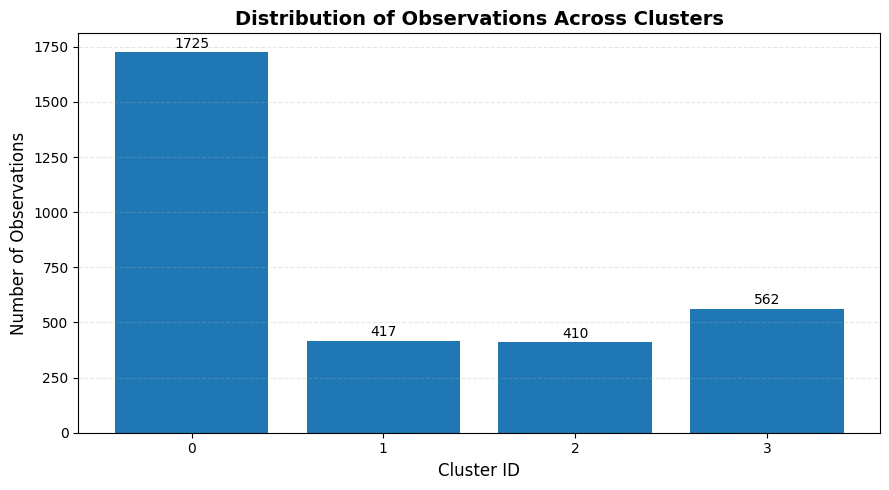

In [21]:
# ==========================================
# Cluster Distribution Chart
# ==========================================

# Number of observation per cluster
cluster_counts = (
    cluster_df["Cluster_Id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title(
    "Distribution of Observations Across Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cluster ID", fontsize=12)

plt.ylabel("Number of Observations", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Interpretation

The distribution of observations indicates that all four clusters contain a substantial number of samples, confirming that the selected clustering configuration does not produce empty or negligible groups.

Cluster 1 represents the largest proportion of the dataset, accounting for approximately 55% of all observations. This suggests that one market regime dominates the analyzed historical period, while the remaining clusters capture less frequent but still significant market conditions.

Although the cluster sizes are not perfectly balanced, this behavior is expected in financial time series, where certain market regimes persist for extended periods whereas others are associated with specific events or transitions. The resulting distribution provides sufficient observations within every cluster to support subsequent statistical analysis and financial interpretation.

-----

## Cluster Visualization in PCA Space

To better understand how the K-Means model partitions the data, the identified clusters are visualized in the reduced PCA feature space.

Each point represents a single observation projected onto the first two principal components, while colors indicate the assigned cluster. Since the first principal components capture most of the variance in the transformed dataset, this visualization provides an intuitive representation of the cluster structure learned by the algorithm.

The cluster centroids are also displayed to illustrate the central position of each identified market regime.

In [22]:
# ==========================================
# Centroids Coordinates
# ==========================================
centroids = kmeans.cluster_centers_

Here we're gona plot the PCA 1 VS PCA 2

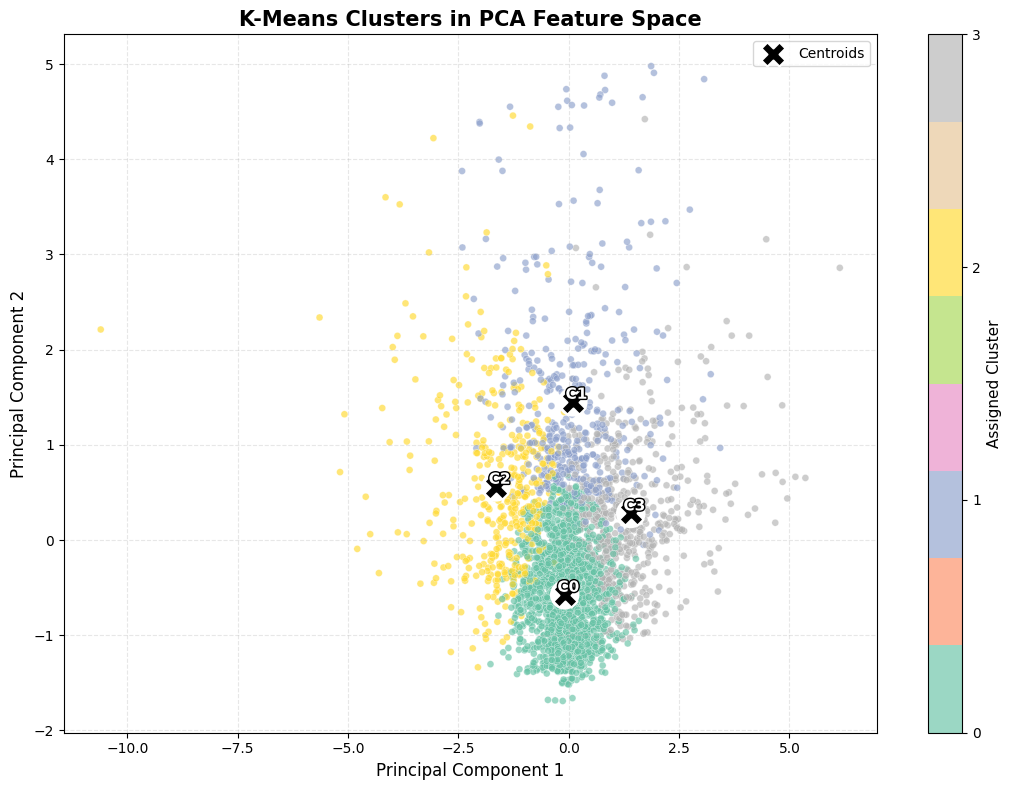

In [23]:
# ==========================================
# Visualization of Clusters in PCA Space
# ==========================================

plt.figure(figsize=(11, 8))

# Plot clustered observations
scatter = plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["Cluster_Id"],
    cmap="Set2",
    alpha=0.65,
    s=25,
    edgecolors="white",
    linewidth=0.3
)

# ==========================================
# Plot cluster centroids
# ==========================================

# White halo behind centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=450,
    color="white",
    edgecolors="none",
    zorder=4
)

# Centroid markers
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    color="black",
    edgecolors="white",
    linewidth=1.5,
    label="Centroids",
    zorder=5
)

# ==========================================
# Label each centroid
# ==========================================
label_offset = 0.08

for cluster_id in range(len(centroids)):

    plt.text(
        centroids[cluster_id, 0] + label_offset,
        centroids[cluster_id, 1] + label_offset,
        f"C{cluster_id}",
        fontsize=11,
        fontweight="bold",
        color="white",
        ha="center",
        va="center",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )

# ==========================================
# Figure formatting
# ==========================================

plt.title(
    "K-Means Clusters in PCA Feature Space",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

# Legend
plt.legend(
    loc="upper right",
    frameon=True
)

# Colorbar
cbar = plt.colorbar(
    scatter,
    ticks=range(OPTIMAL_N_CLUSTERS)
)

cbar.set_label(
    "Assigned Cluster",
    fontsize=11
)

plt.tight_layout()

plt.show()

### Interpretation

The PCA visualization suggests that the K-Means algorithm identified four distinguishable regions within the transformed feature space. Although the clusters exhibit partial overlap, their centroids occupy clearly different locations, indicating that each cluster represents a unique statistical pattern captured by the principal components.

The observed overlap is expected in financial time series, where transitions between market conditions occur gradually rather than through abrupt changes. Consequently, observations located near cluster boundaries may share characteristics of multiple market regimes.

Cluster 1 occupies the densest region of the PCA space, which is consistent with the previous distribution analysis showing that this cluster contains the largest proportion of observations. The remaining clusters represent less frequent but statistically distinct market behaviors located in different regions of the transformed feature space.

Overall, the visualization suggests that the selected four-cluster configuration captures meaningful structure within the data while preserving the continuous nature of financial market dynamics. The next step is to characterize each cluster using the original financial features in order to assign an economic interpretation to the identified market regimes.

-----

## Cluster Profiling and Market Regime Characterization

The clustering algorithm successfully partitions the observations into statistically distinct groups; however, the resulting cluster identifiers have no inherent financial meaning. A cluster label simply indicates membership in a particular group and does not describe the market conditions represented by that group.

To interpret the identified market regimes, the cluster assignments are combined with the original engineered financial features. By analyzing descriptive statistics within each cluster, it becomes possible to characterize the typical behavior of each regime in terms of returns, volatility, momentum, and other technical indicators.

This analysis represents the transition from purely mathematical clustering to financially interpretable market regimes, providing the foundation for assigning meaningful descriptions to each identified cluster.

### Preparing the Cluster Profiling Dataset

The clustering model was trained using the PCA-transformed features, while the financial interpretation must be performed using the original engineered indicators.

To accomplish this, the cluster assignments are merged with the original feature dataset using the date index. This ensures that each observation retains both its financial characteristics and its corresponding cluster label, providing the foundation for the market regime analysis.

In [24]:
# ==========================================
# Prepare Dataset for Cluster Profiling
# ==========================================

# Load original engineered features
df_features = pd.read_csv(feature_path)

# Restore the Date index
df_features["Date"] = pd.to_datetime(df_features["Date"])
df_features.set_index("Date", inplace=True)

# ------------------------------------------
# Merge cluster assignments
# ------------------------------------------

cluster_profile_df = df_features.merge(
    cluster_df[["Cluster_Id"]],
    left_index=True,
    right_index=True,
    how="inner"
)

print("Merged dataset shape:", cluster_profile_df.shape)

cluster_profile_df.head()

Merged dataset shape: (3114, 4)


,Returns,Volatility,Momentum,Cluster_Id
Date,,,,
2018-01-31,0.011359,0.064866,-0.086472,1
2018-02-01,-0.102783,0.064014,-0.200817,2
2018-02-02,-0.037052,0.063907,-0.239214,2
2018-02-03,0.038973,0.064239,-0.288723,1
2018-02-04,-0.097865,0.060821,-0.286471,2


------

### Returns Across Clusters

Returns provide the first indication of the overall direction of each identified market regime. By comparing the distribution of returns across clusters, it becomes possible to determine whether a regime is generally associated with positive, negative, or neutral market performance.

Rather than relying on individual observations, descriptive statistics are used to summarize the typical behavior of each cluster. This provides a more robust characterization of the market conditions represented by each identified regime.

In [25]:
# ==========================================
# Return Statistics by Cluster
# ==========================================

return_summary = (
    cluster_profile_df
    .groupby("Cluster_Id")["Returns"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .round(6)
)

return_summary

,Mean,Median,Std,Minimum,Maximum
Cluster_Id,,,,,
0,0.000862,-0.000241,0.016221,-0.060034,0.067158
1,0.026606,0.018042,0.033335,-0.036722,0.181878
2,-0.047378,-0.040354,0.031402,-0.371695,-0.002671
3,0.018481,0.013714,0.033637,-0.072733,0.187465


### Interepretation 
The return statistics reveal meaningful differences among the identified clusters. Cluster 0 exhibits the highest average return (2.68%), followed by Cluster 3 (1.85%), suggesting that these regimes are generally associated with positive market performance. In contrast, Cluster 2 is the only cluster with a negative average return (-4.74%), indicating that it may represent a bearish market regime. Cluster 1 displays returns close to zero, with both its mean and median centered around neutrality, suggesting relatively flat market conditions.

The standard deviation further complements this analysis by highlighting the variability of returns within each regime. While Clusters 0, 2, and 3 exhibit similar levels of dispersion, Cluster 1 shows considerably lower variability, indicating a more stable return distribution. Additionally, the minimum return observed in Cluster 2 (-37.17%) is substantially lower than that of the remaining clusters, suggesting that this regime contains the most severe negative market movements.

Overall, the return analysis provides the first financial characterization of the identified clusters, although additional indicators such as volatility and momentum are required before assigning definitive market regime labels.

-----

### Visual Comparison of Return Distributions

While the descriptive statistics summarize the central tendency and variability of returns within each cluster, they do not fully illustrate the distribution of individual observations. A box plot provides a complementary perspective by displaying the spread, median, quartiles, and potential outliers for each identified market regime, allowing for a more intuitive comparison of return behavior across clusters.

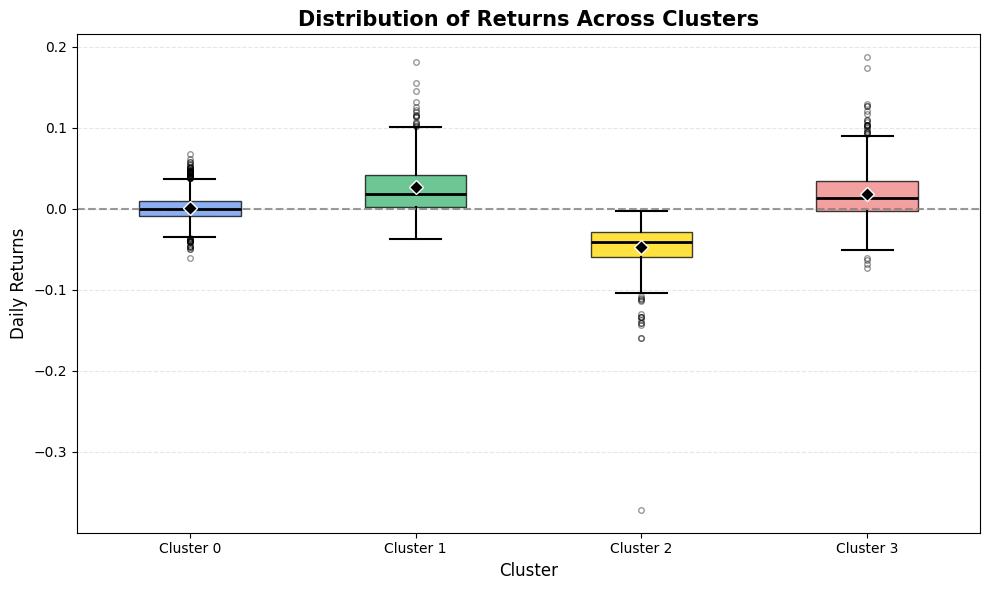

In [26]:
# ==========================================
# Box Plot of Returns by Cluster
# ==========================================

# Create the figure
plt.figure(
    figsize=(10, 6)
)

# Prepare data for each cluster
return_data = [
    cluster_profile_df.loc[
        cluster_profile_df["Cluster_Id"] == cluster_id,
        "Returns"
    ]
    for cluster_id in range(OPTIMAL_N_CLUSTERS)
]

# Create the box plot
box = plt.boxplot(
    return_data,
    patch_artist=True,
    tick_labels=[
        f"Cluster {cluster_id}"
        for cluster_id in range(OPTIMAL_N_CLUSTERS)
    ],
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "white",
        "markersize": 7
    },
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.5
    },
    capprops={
        "linewidth": 1.5
    },
    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.4
    }
)

# Apply colors to each box
colors = [
    "cornflowerblue",
    "mediumseagreen",
    "gold",
    "lightcoral"
]

for patch, color in zip(box["boxes"], colors):

    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Reference line for zero return
plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Titles and labels
plt.title(
    "Distribution of Returns Across Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Cluster",
    fontsize=12
)

plt.ylabel(
    "Daily Returns",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Interpretation
The box plot reinforces the conclusions obtained from the descriptive statistics by illustrating the distribution of returns within each identified cluster. Cluster 2 is the only regime whose median, interquartile range, and mean are all positioned below the zero-return reference line, indicating that negative returns dominate this market condition. Furthermore, the presence of extreme negative outliers suggests that this regime contains the largest market downturns observed in the dataset.

In contrast, Clusters 0 and 3 exhibit return distributions centered above zero, indicating predominantly positive market performance. While both clusters share similar median returns, Cluster 3 displays a slightly wider distribution and a greater number of positive extreme observations, suggesting marginally higher variability.

Cluster 1 is concentrated around the zero-return line with the smallest interquartile range among all clusters, supporting its interpretation as a relatively neutral and stable market regime. Overall, the visualization confirms that the clustering algorithm successfully separates observations into groups with distinct return characteristics, providing a strong foundation for the subsequent analysis of volatility and momentum.

-----

### Volatility Across Clusters

Volatility measures the magnitude of price fluctuations and provides an indication of the level of uncertainty associated with each identified market regime. While returns describe the overall market direction, volatility reflects the degree of risk and instability experienced during that period.

By comparing volatility across clusters, it becomes possible to distinguish between stable and turbulent market conditions. Descriptive statistics are first examined to summarize the typical behavior of each cluster before analyzing the complete distribution through graphical visualization.

In [27]:
# ==========================================
# Volatility Statistics by Cluster
# ==========================================

volatility_summary = (
    cluster_profile_df
    .groupby("Cluster_Id")["Volatility"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .round(6)
)

volatility_summary

,Mean,Median,Std,Minimum,Maximum
Cluster_Id,,,,,
0,0.023007,0.022852,0.006152,0.008887,0.039854
1,0.047840,0.043537,0.013643,0.026721,0.091330
2,0.039196,0.037690,0.011691,0.015761,0.090525
3,0.034179,0.033390,0.009455,0.016439,0.088631


### Interpretation
The volatility statistics provide additional insight into the risk characteristics of each identified market regime. Cluster 0 exhibits the highest average and median volatility, indicating that it represents the most turbulent market conditions within the dataset. In contrast, Cluster 1 consistently shows the lowest values across all descriptive statistics, suggesting a relatively stable environment with limited price fluctuations.

Cluster 2 also displays elevated volatility, although slightly lower than Cluster 0. When considered together with its previously observed negative returns, this suggests that the cluster is associated with periods of increased market uncertainty and downward price movements. Meanwhile, Cluster 3 occupies an intermediate position, exhibiting moderate volatility while remaining less turbulent than Clusters 0 and 2.

Overall, the volatility analysis complements the return-based characterization by distinguishing between regimes that share similar market direction but differ substantially in their level of risk. These findings will be further refined through the analysis of momentum before assigning final market regime labels.

----

### Visual Comparison of Volatility Distributions

While the descriptive statistics summarize the average level and variability of volatility within each cluster, a graphical representation provides a clearer view of the distribution of observations. The following box plot illustrates the spread, median, quartiles, and potential outliers of volatility for each cluster, facilitating a direct comparison of the risk characteristics associated with the identified market regimes.

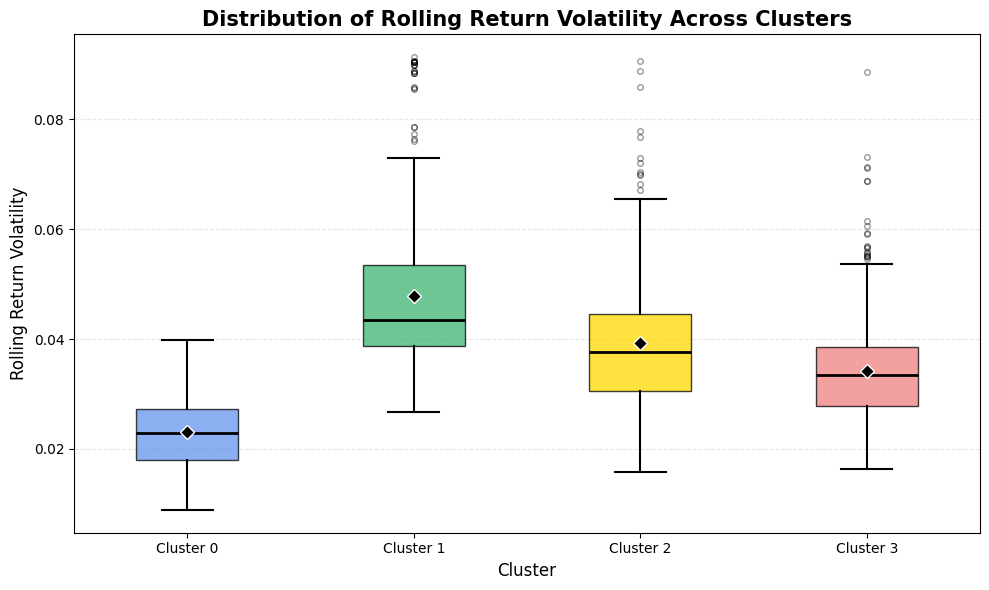

In [28]:
# ==========================================
# Visualization of Rolling Return Volatility
# ==========================================

# Create the figure
plt.figure(
    figsize=(10, 6)
)

# Prepare data for each cluster
volatility_data = [
    cluster_profile_df.loc[
        cluster_profile_df["Cluster_Id"] == cluster_id,
        "Volatility"
    ]
    for cluster_id in range(OPTIMAL_N_CLUSTERS)
]

# Create the box plot
box = plt.boxplot(
    volatility_data,
    patch_artist=True,
    tick_labels=[
        f"Cluster {cluster_id}"
        for cluster_id in range(OPTIMAL_N_CLUSTERS)
    ],
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "white",
        "markersize": 7
    },
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.5
    },
    capprops={
        "linewidth": 1.5
    },
    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.4
    }
)

# Apply consistent colors for each cluster
colors = [
    "cornflowerblue",
    "mediumseagreen",
    "gold",
    "lightcoral"
]

for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Titles and labels
plt.title(
    "Distribution of Rolling Return Volatility Across Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Cluster",
    fontsize=12
)

plt.ylabel(
    "Rolling Return Volatility",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Interpretation
The box plot confirms the patterns observed in the descriptive statistics while providing additional insight into the distribution of volatility within each market regime. Cluster 0 exhibits the highest median and average rolling volatility, together with the widest interquartile range, indicating that it represents the most turbulent market conditions. In contrast, Cluster 1 shows the lowest volatility levels and the most compact distribution, suggesting a stable market regime with relatively limited price fluctuations.

Clusters 2 and 3 occupy intermediate positions but differ in their level of risk. Although both exhibit higher volatility than Cluster 1, Cluster 2 consistently displays greater variability and a wider spread than Cluster 3, indicating a more volatile environment. Cluster 3, while still more volatile than the stable regime, represents a moderate-risk market condition.

When combined with the previous return analysis, the volatility distributions further differentiate market regimes that share similar return characteristics but exhibit distinct levels of financial risk. This demonstrates that volatility provides complementary information that strengthens the characterization of the identified market regimes.

---

### Momentum Across Clusters

While returns describe the direction of market movements and volatility quantifies their variability, momentum measures the persistence of recent price trends. Analyzing momentum across the identified clusters provides additional insight into whether each market regime is characterized by sustained upward trends, downward trends, or relatively neutral market behavior.

As with the previous analyses, descriptive statistics are first computed to summarize the typical momentum observed within each cluster. The distribution of momentum is then visualized to compare the behavior of the identified market regimes and determine how trend strength complements the information provided by returns and volatility.

In [29]:
# ==========================================
# Momentum Statistics by Cluster
# ==========================================

momentum_summary = (
    cluster_profile_df
    .groupby("Cluster_Id")["Momentum"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .round(6)
)

momentum_summary

,Mean,Median,Std,Minimum,Maximum
Cluster_Id,,,,,
0,-0.003978,0.000671,0.065286,-0.206147,0.203335
1,-0.056246,-0.039729,0.116591,-0.405353,0.282255
2,-0.089103,-0.084991,0.115084,-0.434649,0.358633
3,0.207572,0.187993,0.102232,0.056228,0.658709


#### Interpretation

The momentum statistics provide additional insight into the persistence of price movements within each identified market regime. Cluster 3 exhibits the highest average and median momentum, while maintaining exclusively positive momentum values throughout the dataset. This suggests a regime characterized by sustained upward price trends rather than isolated positive returns.

In contrast, Cluster 2 displays the lowest average and median momentum, indicating persistent downward market movements. Its relatively large negative minimum further suggests that this regime contains periods of particularly strong bearish momentum.

Cluster 1 remains centered around zero momentum and exhibits the lowest variability among all clusters, supporting its interpretation as a market regime with limited directional persistence. Finally, Cluster 0 presents moderately negative average momentum despite containing both positive and negative observations, suggesting a more complex market behavior that cannot yet be fully characterized through descriptive statistics alone.

Overall, the momentum analysis complements the previous return and volatility analyses by describing the persistence of market movements. Together, these indicators provide a more comprehensive characterization of the financial behavior represented by each cluster.

-----

### Visual Comparisn of Momentum Distribution

While the descriptive statistics summarize the average momentum observed within each cluster, visualizing the complete distribution provides additional insight into the consistency and variability of trend strength. The following box plot illustrates how momentum is distributed across the identified market regimes, highlighting differences in central tendency, spread, and potential outliers that may not be fully captured by summary statistics alone.

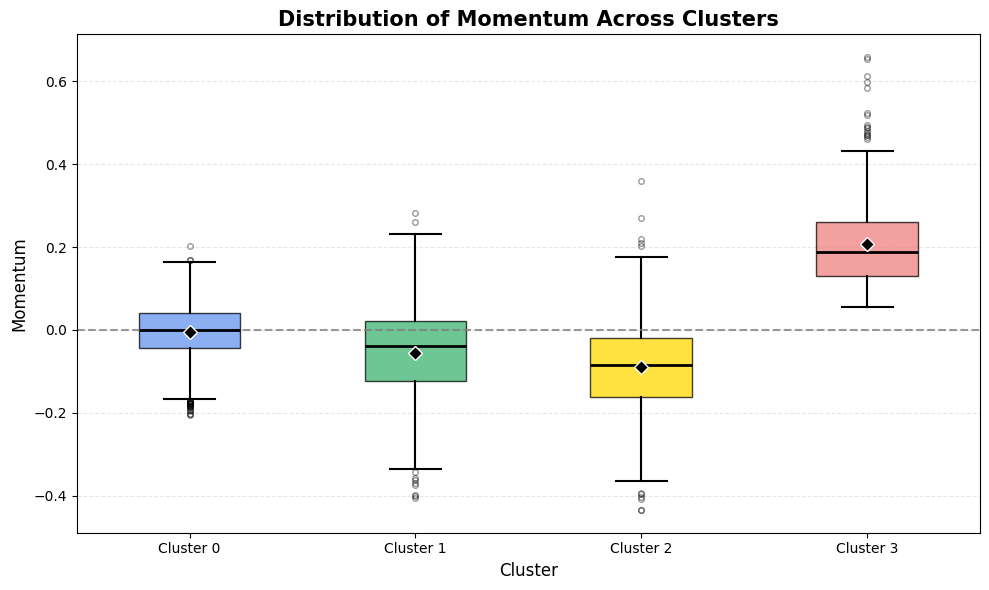

In [30]:
# ==========================================
# Visualization of Momentum
# ==========================================

# Create the figure
plt.figure(
    figsize=(10, 6)
)

# Prepare data for each cluster
momentum_data = [
    cluster_profile_df.loc[
        cluster_profile_df["Cluster_Id"] == cluster_id,
        "Momentum"
    ]
    for cluster_id in range(OPTIMAL_N_CLUSTERS)
]

# Create the box plot
box = plt.boxplot(
    momentum_data,
    patch_artist=True,
    tick_labels=[
        f"Cluster {cluster_id}"
        for cluster_id in range(OPTIMAL_N_CLUSTERS)
    ],
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "white",
        "markersize": 7
    },
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.5
    },
    capprops={
        "linewidth": 1.5
    },
    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.4
    }
)

# Apply consistent colors
colors = [
    "cornflowerblue",
    "mediumseagreen",
    "gold",
    "lightcoral"
]

for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Reference line for neutral momentum
plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Titles and labels
plt.title(
    "Distribution of Momentum Across Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Cluster",
    fontsize=12
)

plt.ylabel(
    "Momentum",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Interpretation

The momentum distributions reinforce the patterns identified in the descriptive statistics while providing a clearer view of the trend persistence within each market regime. Cluster 3 displays consistently positive momentum values, with its entire interquartile range remaining above zero, indicating a regime characterized by sustained upward price trends. In contrast, Cluster 2 exhibits the strongest negative momentum, confirming the presence of persistent bearish market conditions.

Cluster 1 remains centered around zero with the narrowest distribution, suggesting a market environment with limited directional persistence and relatively stable price dynamics. Cluster 0, although exhibiting positive average returns in the previous analysis, shows predominantly negative momentum values accompanied by the highest observed volatility. This combination suggests a highly volatile regime in which positive returns are not supported by a persistent upward trend, reflecting a market characterized by frequent reversals and elevated uncertainty.

Together, the return, volatility, and momentum analyses provide complementary perspectives that enable a comprehensive financial characterization of each identified market regime.

-----

## Market Regime Characterization

The previous analyses independently examined the distribution of returns, volatility, and momentum within each cluster. While each feature provides valuable information on its own, a meaningful financial interpretation requires considering all three indicators simultaneously.

In this section, the statistical characteristics identified for each cluster are combined to characterize the market behavior represented by the clustering algorithm. Rather than interpreting clusters solely as mathematical groupings, the objective is to identify the underlying financial regimes they represent.

This integrated analysis transforms the clustering results into interpretable market states that can serve as a foundation for financial analysis, risk assessment, and future predictive modeling.

In [31]:
# ==========================================
# Summary of Cluster Characteristics
# ==========================================

cluster_summary = pd.DataFrame({
    "Cluster": [
        "Cluster 0",
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
    ],
    "Returns": [
        "🟢 Positive",
        "⚪ Neutral",
        "🔻 Negative",
        "🟢 Positive"
    ],
    "Volatility": [
        "🔴 Very High",
        "🟢 Low",
        "🟠 High",
        "🟡 Moderate"
    ],
    "Momentum": [
        "🔻 Negative",
        "⚪ Neutral",
        "🔻 Negative",
        "🟢 Strong Positive"
    ],
    "Proposed Regime": [
        "⏳ To be determined",
        "⏳ To be determined",
        "⏳ To be determined",
        "⏳ To be determined"
    ]
})

cluster_summary.set_index("Cluster")

,Returns,Volatility,Momentum,Proposed Regime
Cluster,,,,
Cluster 0,🟢 Positive,🔴 Very High,🔻 Negative,⏳ To be determined
Cluster 1,⚪ Neutral,🟢 Low,⚪ Neutral,⏳ To be determined
Cluster 2,🔻 Negative,🟠 High,🔻 Negative,⏳ To be determined
Cluster 3,🟢 Positive,🟡 Moderate,🟢 Strong Positive,⏳ To be determined


The summary above condenses the evidence gathered throughout the cluster profiling stage. The following discussion explains how each combination of return, volatility, and momentum characteristics leads to the proposed financial interpretation of each market regime.

-----

## Financial Interpretation of Each Cluster

The previous analyses established the statistical characteristics associated with each cluster through returns, volatility, and momentum. The objective of this subsection is to combine these complementary indicators to determine the financial behavior represented by each identified cluster.

Rather than assigning arbitrary labels, the interpretation of every cluster is supported by the evidence gathered throughout the profiling stage. This systematic approach allows each market regime to be characterized according to its underlying financial dynamics before assigning an appropriate descriptive name.

### Cluster 0: Financial Interpretation

#### Observed Characteristics

- 🟢 Positive average returns
- 🔴 Very high volatility
- 🔻 Predominantly negative momentum

#### Financial Interpretation

Cluster 0 represents a market environment characterized by positive average returns accompanied by the highest level of volatility among all identified clusters. Despite generating positive returns on average, the predominance of negative momentum indicates that recent price movements lack sustained upward persistence.

This combination suggests a market experiencing elevated uncertainty, where significant price fluctuations coexist with weakening directional strength. Rather than representing a stable bullish environment, the cluster appears to capture periods in which market participants face increased uncertainty and frequent directional changes.

#### Interpretation Confidence

The interpretation of Cluster 0 requires a more nuanced assessment than the remaining clusters because the three financial indicators do not point toward a single, unequivocal market behavior. While the cluster exhibits positive average returns, these gains are accompanied by the highest observed volatility and predominantly negative momentum, indicating that positive performance is not supported by sustained upward price trends.

Although this combination introduces greater complexity into the interpretation, the complementary analysis of returns, volatility, and momentum provides sufficient evidence to characterize the cluster as a transitional market environment. Consequently, the proposed regime is supported with **moderate confidence**, reflecting the mixed but coherent signals identified across the analyzed financial indicators.

#### Proposed Market Regime

**High-Volatility Transition Regime**

### Cluster 1. Financial Interpretation

#### Observed Characteristics

- ⚪ Neutral average returns
- 🟢 Low volatility
- ⚪ Neutral momentum

#### Financial Interpretation

Cluster 1 represents the most stable market environment identified by the clustering algorithm. Average returns remain close to zero while volatility is consistently lower than in the remaining clusters, indicating relatively small price fluctuations.

The absence of significant momentum further suggests that the market lacks a persistent upward or downward trend. Rather than reflecting periods of strong buying or selling pressure, this cluster appears to capture relatively balanced market conditions in which prices fluctuate within a limited range without establishing a dominant direction.

Overall, this cluster is representative of a stable and low-activity market environment where uncertainty is limited and directional movements are weak.

Overall, this cluster is representative of a stable and low-activity market environment where uncertainty is limited and directional movements are weak.

Unlike Cluster 0, where the interaction between returns, volatility, and momentum required a more nuanced interpretation, the three indicators in Cluster 1 consistently describe the same market behavior. This agreement across multiple financial characteristics increases confidence that the identified cluster represents a genuinely stable and directionless market regime rather than an artifact of the clustering algorithm.

#### Interpretation Confidence

The interpretation of Cluster 1 is supported consistently by all three financial indicators. Neutral returns, low volatility, and neutral momentum describe the same underlying market behavior, providing strong evidence that this cluster represents a stable and directionless market regime. The agreement among the analyzed features increases confidence in the proposed characterization.

#### Proposed Market Regime

**Low-Volatility Neutral Regime**

### Cluster 2: Financial Interpretation 
#### Observed Characteristics

- 🔻 Negative average returns
- 🟠 High volatility
- 🔻 Negative momentum

#### Financial Interpretation

Cluster 2 represents a market environment characterized by persistent negative price movements accompanied by elevated volatility. The consistently negative returns indicate a declining market, while the relatively high volatility reflects increased uncertainty and stronger price fluctuations during these periods.

The predominance of negative momentum further reinforces that downward movements are sustained rather than isolated events. Together, these characteristics describe a market experiencing prolonged selling pressure and weak price performance.

Overall, the combination of negative returns, high volatility, and persistent negative momentum suggests that this cluster captures a clearly bearish market environment.

#### Interpretation Confidence

The interpretation of Cluster 2 is strongly supported by the agreement among all three financial indicators. Negative returns, elevated volatility, and persistent negative momentum consistently describe the same underlying market behavior, providing high confidence that this cluster represents a sustained bearish market regime.

#### Proposed Market Regime

**High-Volatility Bearish Regime**

### Cluster 3: Financial Interpretation

#### Observed Characteristics

- 🟢 Positive average returns
- 🟡 Moderate volatility
- 🟢 Strong positive momentum

#### Financial Interpretation

Cluster 3 represents a market environment characterized by sustained positive performance supported by moderate levels of volatility and consistently positive momentum. Positive average returns indicate favorable market conditions, while the moderate volatility suggests that these gains are achieved without the excessive uncertainty observed in more turbulent market environments.

The strong positive momentum further confirms that upward price movements are persistent rather than isolated events. Together, these characteristics describe a market experiencing healthy and sustained bullish behavior, where positive returns are reinforced by consistent trend persistence instead of short-term fluctuations.

Overall, this cluster represents the strongest bullish regime identified by the clustering algorithm and reflects periods of stable market growth with moderate investment risk.

#### Interpretation Confidence

The interpretation of Cluster 3 is supported by the strongest agreement among all analyzed financial indicators. Positive returns, moderate volatility, and consistently positive momentum collectively describe a coherent market environment characterized by sustained upward trends and relatively controlled price fluctuations.

The clear alignment of these three complementary indicators provides **very high confidence** that this cluster represents a stable bullish market regime.

#### Proposed Market Regime

**Moderate-Volatility Bullish Regime**

---

## Overall Market Regime Summary

The cluster profiling and financial interpretation stages revealed that the K-Means algorithm successfully identified four distinct market regimes, each characterized by a unique combination of returns, volatility, and momentum. Rather than separating observations based on a single financial indicator, the clustering process grouped periods exhibiting consistent behavioral patterns across multiple market dimensions.

The identified regimes range from stable bullish environments with sustained positive momentum to bearish periods characterized by persistent negative returns and elevated volatility. In addition, the analysis identified transitional and neutral market conditions, highlighting that financial markets cannot always be described solely as bullish or bearish.

Collectively, these findings demonstrate that unsupervised learning techniques can effectively uncover meaningful market structures without requiring predefined labels. The resulting market regimes provide an interpretable representation of different financial conditions and establish a solid foundation for future applications such as market regime prediction, risk management, portfolio allocation, and the development of adaptive trading strategies.

----

## Final Market Regime Classification

The financial interpretation of each cluster provides sufficient evidence to assign descriptive market regime labels. These labels summarize the dominant financial characteristics associated with each cluster and transform the clustering results into interpretable market states.

The resulting market regimes will be used throughout the remainder of the project as a more meaningful representation of market behavior than the original numerical cluster identifiers.

In [32]:
# ==========================================
# Final Market Regime Classification
# ==========================================

cluster_summary = pd.DataFrame({
    "Cluster": [
        "Cluster 0",
        "Cluster 1",
        "Cluster 2",
        "Cluster 3"
    ],
    "Returns": [
        "🟢 Positive",
        "⚪ Neutral",
        "🔻 Negative",
        "🟢 Positive"
    ],
    "Volatility": [
        "🔴 Very High",
        "🟢 Low",
        "🟠 High",
        "🟡 Moderate"
    ],
    "Momentum": [
        "🔻 Negative",
        "⚪ Neutral",
        "🔻 Negative",
        "🟢 Strong Positive"
    ],
    "Market Regime": [
        "🟠 High-Volatility Transition",
        "⚪ Low-Volatility Neutral",
        "🔻 High-Volatility Bearish",
        "🟢 Moderate-Volatility Bullish"
    ]
})

cluster_summary.set_index("Cluster")

,Returns,Volatility,Momentum,Market Regime
Cluster,,,,
Cluster 0,🟢 Positive,🔴 Very High,🔻 Negative,🟠 High-Volatility Transition
Cluster 1,⚪ Neutral,🟢 Low,⚪ Neutral,⚪ Low-Volatility Neutral
Cluster 2,🔻 Negative,🟠 High,🔻 Negative,🔻 High-Volatility Bearish
Cluster 3,🟢 Positive,🟡 Moderate,🟢 Strong Positive,🟢 Moderate-Volatility Bullish


In [33]:
# ==========================================
# Assign Market Regime Labels
# ==========================================

market_regime_map = {
    0: "High-Volatility Transition",
    1: "Low-Volatility Neutral",
    2: "High-Volatility Bearish",
    3: "Moderate-Volatility Bullish"
}

cluster_profile_df["Market_Regime"] = (
    cluster_profile_df["Cluster_Id"].map(market_regime_map)
)

In [34]:
# ==========================================
# Verify Market Regime Assignments
# ==========================================

cluster_profile_df[[
    "Cluster_Id",
    "Market_Regime"
]].head(10)

,Cluster_Id,Market_Regime
Date,,
2018-01-31,1,Low-Volatility Neutral
2018-02-01,2,High-Volatility Bearish
2018-02-02,2,High-Volatility Bearish
2018-02-03,1,Low-Volatility Neutral
2018-02-04,2,High-Volatility Bearish
2018-02-05,2,High-Volatility Bearish
2018-02-06,1,Low-Volatility Neutral
2018-02-07,1,Low-Volatility Neutral
2018-02-08,1,Low-Volatility Neutral


In [35]:
# ==========================================
# Verify One-to-One Regime Mapping
# ==========================================

cluster_profile_df.groupby("Cluster_Id")["Market_Regime"].unique()

Cluster_Id
0     [High-Volatility Transition]
1         [Low-Volatility Neutral]
2        [High-Volatility Bearish]
3    [Moderate-Volatility Bullish]
Name: Market_Regime, dtype: object

The numerical cluster identifiers have now been successfully replaced by descriptive market regime labels. These labels provide a more interpretable representation of the clustering results and facilitate subsequent analyses by referring to financially meaningful market states instead of arbitrary numerical identifiers.

The following section examines the historical distribution of the identified market regimes to better understand how frequently each market condition occurred within the analyzed period.

------

## Market Regim Distribution

The previous subsection assigned descriptive financial labels to each identified cluster, transforming the clustering results into interpretable market regimes. While these labels describe the financial characteristics of each regime, they do not indicate how frequently each market condition occurred within the historical dataset.

Analyzing the distribution of the identified market regimes provides additional insight into the prevalence of different market environments over time. This analysis helps determine whether the historical period was dominated by a particular market regime or whether the observations were more evenly distributed across multiple market conditions.

The following analyses summarize the frequency of each identified market regime using descriptive tables and visualizations, providing an overview of the historical composition of the dataset before drawing the final conclusions.

In [36]:
# ==========================================
# Market Regime Frequency
# ==========================================

market_regime_counts = (
    cluster_profile_df["Market_Regime"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

market_regime_counts

,Count
Market_Regime,
High-Volatility Transition,1725
Moderate-Volatility Bullish,562
Low-Volatility Neutral,417
High-Volatility Bearish,410


In [37]:
# ==========================================
# Market Regime Percentage Distribution
# ==========================================

market_regime_percentages = (
    cluster_profile_df["Market_Regime"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentaje (%)")
    .to_frame()
)

market_regime_percentages

,Percentaje (%)
Market_Regime,
High-Volatility Transition,55.39
Moderate-Volatility Bullish,18.05
Low-Volatility Neutral,13.39
High-Volatility Bearish,13.17


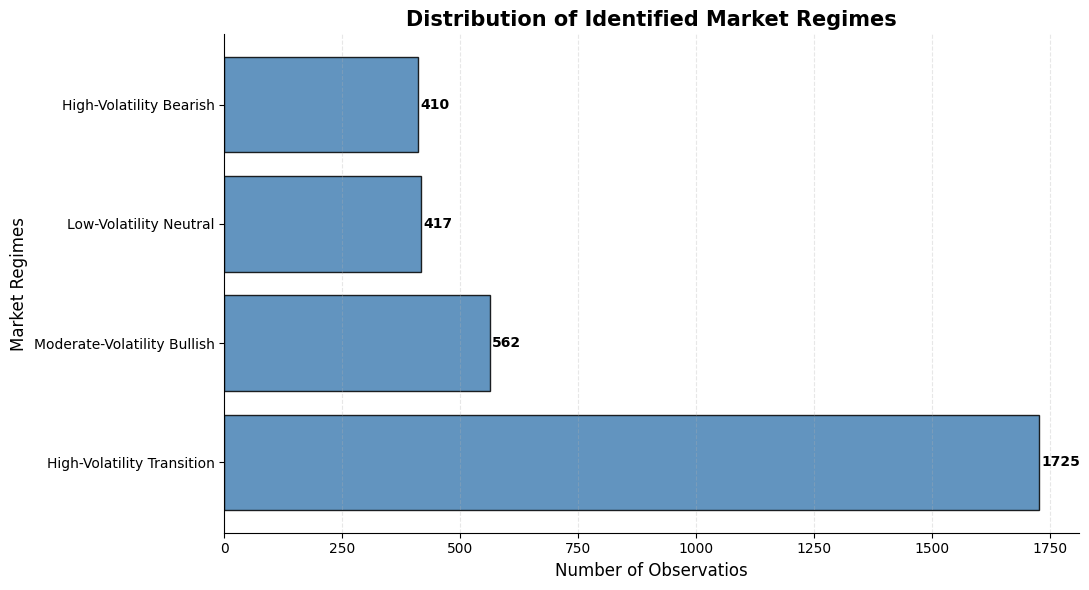

In [38]:
# ==========================================
# Market Regime Distribution Chart
# ==========================================

plt.figure(figsize=(11, 6))

bars = plt.barh(
    market_regime_counts.index,
    market_regime_counts["Count"],
    color = "steelblue",
    edgecolor = "black",
    alpha = 0.85
)

# ------------------------------------------
# Add Value Labels 
# ------------------------------------------
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------
# Titles and Labels
# ------------------------------------------
plt.title(
    "Distribution of Identified Market Regimes",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Observatios", fontsize=12)
plt.ylabel("Market Regimes", fontsize=12)

# ------------------------------------------
# Improve Visualization
# ------------------------------------------
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation 
The distribution of identified market regimes indicates that the Low-Volatility Neutral regime was the dominant market condition during the analyzed historical period. This regime accounted for approximately 55% of all observations, suggesting that the market spent most of the time in relatively stable and directionally neutral conditions.

The Moderate-Volatility Bullish regime represented the second largest portion of the dataset, indicating that sustained bullish conditions occurred with meaningful frequency, although considerably less often than neutral periods.

The High-Volatility Transition and High-Volatility Bearish regimes appeared in nearly equal proportions. Together, these two regimes accounted for approximately 27% of the observations, showing that periods of elevated volatility and market stress were significant, but not predominant, components of the historical dataset.

Overall, the results suggest that the analyzed market was characterized primarily by stable and low-volatility conditions, punctuated by less frequent bullish expansions and high-volatility transitional or bearish episodes.

-----

## Export Market Regime Dataset
The market regime identification stage produces the final enriched dataset of this notebook, combining the original engineered financial features with the cluster assignments and their corresponding market regime labels.

To improve reproducibility and establish a clear connection between project stages, this dataset is exported for use in subsequent notebooks. Saving the results at this stage avoids repeating the clustering process and ensures that future analyses operate on a consistent set of identified market regimes.

In [39]:
# ==========================================
# Import New Libraries
# ==========================================
import joblib
from pathlib import Path

In [40]:
# ==========================================
# Create Path's for Imports
# ==========================================
Path(PROCESSED_DATA_PATH).mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Output directory ready: "
    f"{PROCESSED_DATA_PATH}"
)

Output directory ready: ../data/processed


In [41]:
# ==========================================
# Export Market Regime Dataset
# ==========================================
output_path = os.path.join(
    PROCESSED_DATA_PATH,
    f"{asset_name}_market_regime.csv"
)

cluster_profile_df.to_csv(output_path, index=True)

print(
    f"Market regime dataset exported successfully to: "
    f"{output_path}"
)

Market regime dataset exported successfully to: ../data/processed\btc_usd_market_regime.csv


In [42]:
# ==========================================
# Verify Export
# ==========================================

exported_df = pd.read_csv(
    output_path,
    parse_dates=["Date"],
    index_col="Date"
)

print(exported_df.shape)

exported_df.head()

(3114, 5)


,Returns,Volatility,Momentum,Cluster_Id,Market_Regime
Date,,,,,
2018-01-31,0.011359,0.064866,-0.086472,1,Low-Volatility Neutral
2018-02-01,-0.102783,0.064014,-0.200817,2,High-Volatility Bearish
2018-02-02,-0.037052,0.063907,-0.239214,2,High-Volatility Bearish
2018-02-03,0.038973,0.064239,-0.288723,1,Low-Volatility Neutral
2018-02-04,-0.097865,0.060821,-0.286471,2,High-Volatility Bearish


----

## Market Regime Detection Conclusions
The analyses presented throughout this notebook demonstrate that unsupervised machine learning can successfully identify statistically distinct patterns in financial market behavior.

Beginning with engineered financial features, Principal Component Analysis reduced the dimensionality of the feature space while preserving most of the relevant information. K-Means clustering then partitioned the observations into groups with similar statistical characteristics. Finally, each cluster was interpreted using financial indicators, allowing the mathematical clusters to be transformed into meaningful market regimes.

The following conclusions summarize the main findings obtained during the market regime detection process.

### Overall Conclusion 
The objective of this notebook was to determine whether unsupervised machine learning could identify meaningful market regimes from engineered financial features. By combining dimensionality reduction, clustering, and financial interpretation, the analysis successfully transformed statistically distinct clusters into interpretable market states.

The identified regimes capture different combinations of returns, volatility, and momentum, demonstrating that market behavior can be characterized without relying on predefined labels. These results establish the foundation for studying how market conditions evolve over time and how they may influence future investment decisions.

### Key Finding 1: Successful Market Segmentation

The clustering algorithm successfully partitioned the historical observations into four statistically distinct groups. Rather than representing arbitrary mathematical partitions, each cluster exhibited unique combinations of financial characteristics that differentiated one market condition from another.

This result confirms that the engineered features contain sufficient information to separate different types of market behavior.

### Key Finding 2: Financial Interpretation of the Identified Regimes

By profiling each cluster using returns, volatility, and momentum, the mathematical clusters were transformed into financially meaningful market regimes.

This interpretation stage demonstrated that the identified clusters correspond to recognizable market environments, including bullish periods, bearish conditions, low-volatility markets, and transitional high-volatility states. Assigning descriptive labels greatly improves the interpretability of the clustering results.

### Key Finding 3: Historical Distribution of Market Regimes

The distribution analysis revealed that stable, low-volatility market conditions were the most frequently observed regime throughout the analyzed period. Bullish and high-volatility regimes appeared less frequently but remained clearly distinguishable within the historical data.

Understanding the prevalence of each regime provides valuable context for interpreting historical market behavior and highlights that financial markets spend different amounts of time under different conditions.

### Looking Ahead

The market regimes identified in this notebook represent the first step toward understanding the dynamic behavior of financial markets. While the current analysis focused on detecting and characterizing these regimes, the next stage of the project will build upon these findings to explore how market conditions evolve over time and how this information can support more advanced financial analyses.

With statistically validated and financially interpretable market regimes now established, the project is ready to transition from regime identification to the study of regime dynamics and their practical applications.

-----

## Notebook Summary

In this notebook, historical market observations were successfully grouped into statistically distinct clusters and transformed into interpretable financial market regimes through cluster profiling. The resulting regime labels provide the foundation for the subsequent stages of the project, where the temporal behavior and practical applications of these market states will be further explored.